# NAME: JOHNSON OGBONNAYA
# STUDENT ID: 2423924

# Install Required Libraries

In [58]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

# Import Libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

from joblib import dump

# Load Dataset

In [60]:
df = pd.read_csv("C:/Users/windows 11/student-mat.csv", sep=";")
print("Dataset Loaded. Shape:", df.shape)
df.head()

Dataset Loaded. Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# Encode Categorical Features

In [61]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Create Target Variable

In [62]:
df['pass'] = (df['G3'] >= 10).astype(int)

# Define Features and Target

In [63]:
X = df.drop(['G3', 'pass'], axis=1)
y = df['pass']

# Split the Dataset

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Models

In [67]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(probability=True),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

# Train, Predict, Evaluate and Export Each Model


Training Random Forest...
Model saved as random_forest_model.joblib
Accuracy: 0.9113924050632911
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.93      0.88        27
           1       0.96      0.90      0.93        52

    accuracy                           0.91        79
   macro avg       0.90      0.91      0.90        79
weighted avg       0.92      0.91      0.91        79



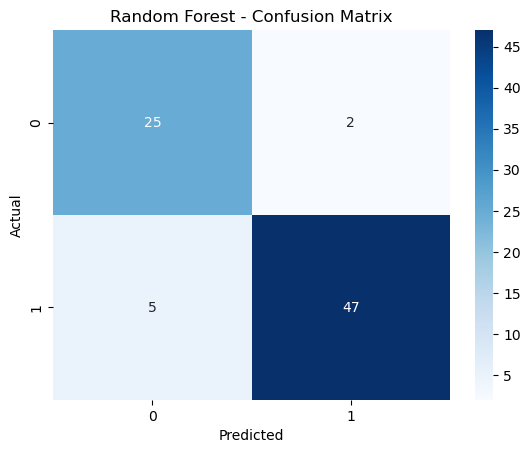


Training Logistic Regression...
Model saved as logistic_regression_model.joblib
Accuracy: 0.9493670886075949
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93        27
           1       0.98      0.94      0.96        52

    accuracy                           0.95        79
   macro avg       0.94      0.95      0.94        79
weighted avg       0.95      0.95      0.95        79



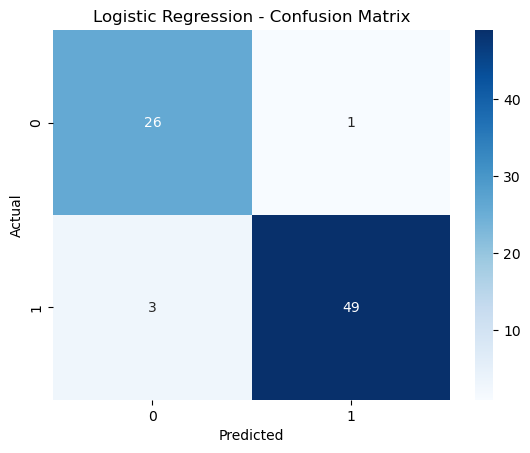


Training Support Vector Machine...
Model saved as support_vector_machine_model.joblib
Accuracy: 0.8860759493670886
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.81      0.83        27
           1       0.91      0.92      0.91        52

    accuracy                           0.89        79
   macro avg       0.88      0.87      0.87        79
weighted avg       0.89      0.89      0.89        79



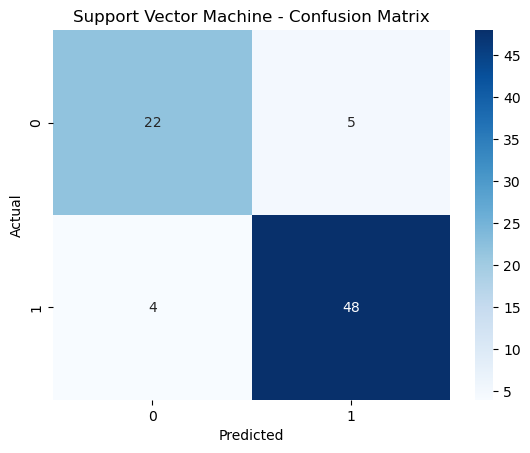


Training XGBoost...
Model saved as xgboost_model.joblib
Accuracy: 0.8734177215189873
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81        27
           1       0.90      0.90      0.90        52

    accuracy                           0.87        79
   macro avg       0.86      0.86      0.86        79
weighted avg       0.87      0.87      0.87        79



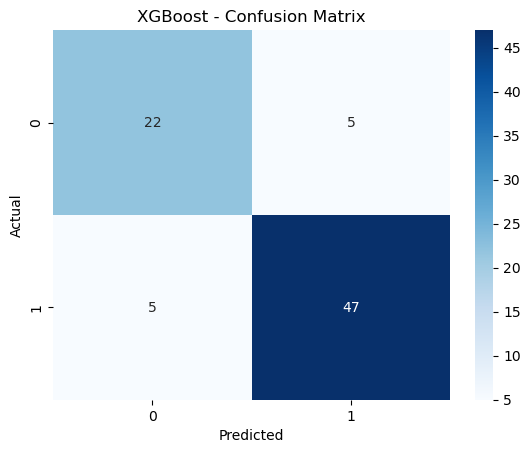

In [68]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Save model
    model_filename = f"{name.lower().replace(' ', '_')}_model.joblib"
    dump(model, model_filename)
    print(f"Model saved as {model_filename}")

    # Evaluation
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    results[name] = acc

# Compare Model Accuracies

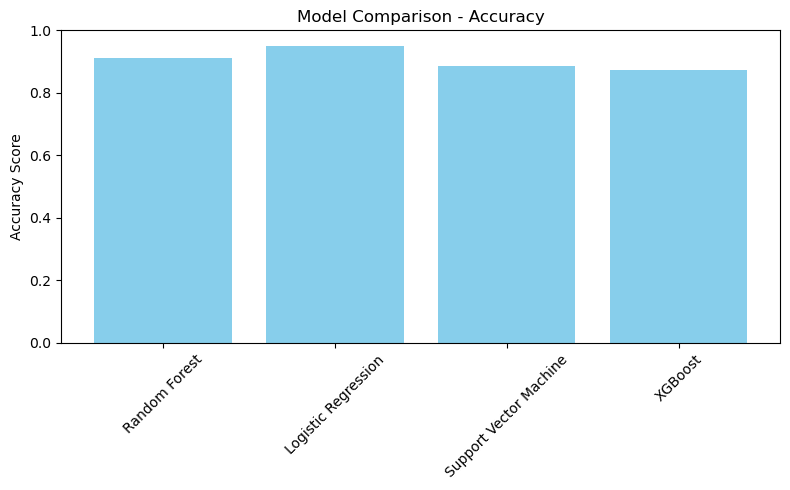

In [69]:
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.title("Model Comparison - Accuracy")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Best Model

In [70]:
best_model_name = max(results, key=results.get)
print(f"\nBest model: {best_model_name} with accuracy of {results[best_model_name]:.2f}")


Best model: Logistic Regression with accuracy of 0.95
